In [43]:
import keras
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd


In [44]:
#using mnist library for digit classsification
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
len(X_train), len(X_test), len(y_train), len(y_test)


(60000, 10000, 60000, 10000)

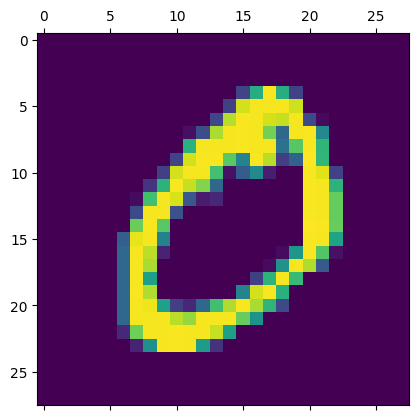

In [45]:
#data image
plt.matshow(X_train[1])

In [46]:
X_train=X_train/255
X_test=X_test/255

In [47]:
#flatteing or converting 2 dim array into single dim array
X_train_flattened=X_train.reshape(len(X_train),28*28)
X_train_flattened.shape
X_test_flattened=X_test.reshape(len(X_test),28*28)
X_test_flattened.shape

(10000, 784)

In [48]:
#creating simple neural network
model=keras.Sequential([
    keras.layers.Dense(10,input_shape=(784,),activation='sigmoid')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(X_train_flattened,y_train,epochs=5)
#accuracy was very low hence we need to scale this data in cell 4

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8806 - loss: 0.4625
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9151 - loss: 0.3031
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9202 - loss: 0.2834
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9238 - loss: 0.2726
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9259 - loss: 0.2668


In [49]:
model.evaluate(X_test_flattened,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9273 - loss: 0.2676


[0.26762625575065613, 0.927299976348877]

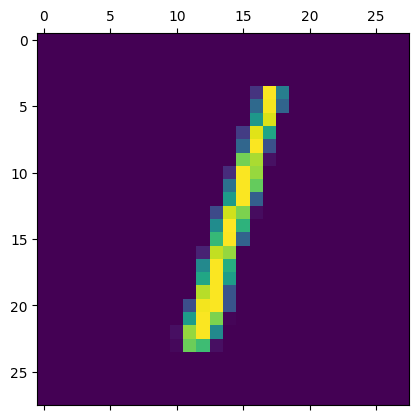

In [56]:
plt.matshow(X_test[2])

In [57]:
y_predict=model.predict(X_test_flattened)
y_predict[2]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([3.0570605e-04, 9.9279594e-01, 6.5852046e-01, 3.6860880e-01,
       3.1457040e-02, 1.0116909e-01, 2.0864533e-01, 1.5030858e-01,
       4.0298626e-01, 4.1477043e-02], dtype=float32)

In [58]:
np.argmax(y_predict[2])

np.int64(1)

In [60]:
y_predict_labels=[np.argmax(i) for i in y_predict]
y_predict_labels[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [61]:
tf.math.confusion_matrix(y_test,y_predict_labels)

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 956,    0,    1,    2,    0,    5,   10,    2,    3,    1],
       [   0, 1112,    3,    2,    0,    1,    4,    2,   11,    0],
       [   3,    9,  932,   17,    9,    3,   13,   10,   33,    3],
       [   1,    0,   19,  931,    0,   18,    2,   13,   22,    4],
       [   1,    1,    3,    1,  925,    0,   11,    4,   10,   26],
       [   9,    3,    2,   39,   10,  767,   19,    7,   30,    6],
       [   7,    3,    4,    1,    7,    8,  925,    2,    1,    0],
       [   1,    5,   23,    7,   10,    0,    0,  959,    4,   19],
       [   4,    8,    8,   23,    9,   24,   10,   12,  871,    5],
       [   9,    7,    2,   11,   36,    6,    0,   32,   11,  895]],
      dtype=int32)>

In [62]:
#creating simple neural network with hidden layers now
model = keras.Sequential([
    keras.layers.Dense(100, input_shape=(784,), activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(X_train_flattened, y_train, epochs=5)
#accuracy was very low hence we need to scale this data in cell 4

C:\Users\rishi\PycharmProjects\DeepLearning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9228 - loss: 0.2735
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9632 - loss: 0.1252
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9743 - loss: 0.0873
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9800 - loss: 0.0663
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9839 - loss: 0.0536


In [63]:
model.evaluate(X_test_flattened, y_test)
#after hidden layer added accuracy improved

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9738 - loss: 0.0817


[0.08169663697481155, 0.973800003528595]

In [64]:
#creating simple neural network without flattening the data indstead using flatten layer
model = keras.Sequential([
     keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(100, input_shape=(784,), activation='sigmoid'),
    keras.layers.Dense(10, activation='sigmoid'),

])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(X_train, y_train, epochs=5)
#accuracy was very low hence we need to scale this data in cell 4

C:\Users\rishi\PycharmProjects\DeepLearning\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8932 - loss: 0.4171
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9424 - loss: 0.2008
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9567 - loss: 0.1490
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9665 - loss: 0.1179
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9729 - loss: 0.0959
